In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Classes Found:
['10_rupee', '1_rupee', '2_rupee', '5_rupee']
10_rupee   : 241 images
1_rupee    : 443 images
2_rupee    : 446 images
5_rupee    : 465 images

Checking dataset...

10_rupee   -> (3888, 5184, 3)
1_rupee    -> (256, 256, 3)
2_rupee    -> (256, 256, 3)
5_rupee    -> (1544, 1544, 3)

Corrupt Images: 0


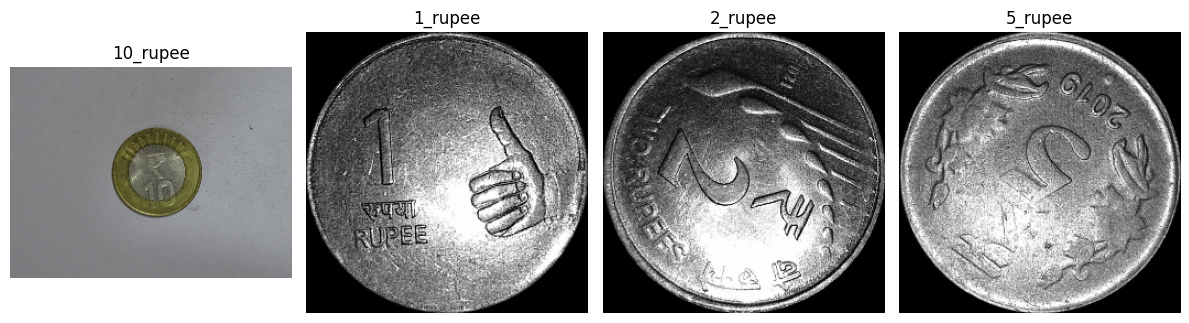

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# ===========================
# CHANGE THIS PATH
# ===========================
dataset_path = "/content/drive/MyDrive/coins_dataset"

# Get class folders
classes = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("="*50)
print("Classes Found:")
print(classes)
print("="*50)

# Count images
for cls in classes:
    folder = os.path.join(dataset_path, cls)

    images = [
        img for img in os.listdir(folder)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{cls:10s} : {len(images)} images")

print("="*50)


# Check image size + corruption
print("\nChecking dataset...\n")

corrupt = 0

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    images = [
        img for img in os.listdir(folder)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    sample = random.choice(images)

    path = os.path.join(folder, sample)

    image = cv2.imread(path)

    if image is None:
        corrupt += 1
        continue

    print(f"{cls:10s} -> {image.shape}")

print("\nCorrupt Images:", corrupt)


# Show one sample from each class
plt.figure(figsize=(12,4))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    images = [
        img for img in os.listdir(folder)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    sample = random.choice(images)

    image = cv2.imread(os.path.join(folder, sample))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# Load Dataset
# ==============================

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_dataset.class_names

print("\nClasses:")
print(class_names)

print("\nNumber of Classes:", len(class_names))

Found 1595 files belonging to 4 classes.
Using 1276 files for training.
Found 1595 files belonging to 4 classes.
Using 319 files for validation.

Classes:
['10_rupee', '1_rupee', '2_rupee', '5_rupee']

Number of Classes: 4


Image Batch Shape : (32, 256, 256, 3)
Label Batch Shape : (32, 4)


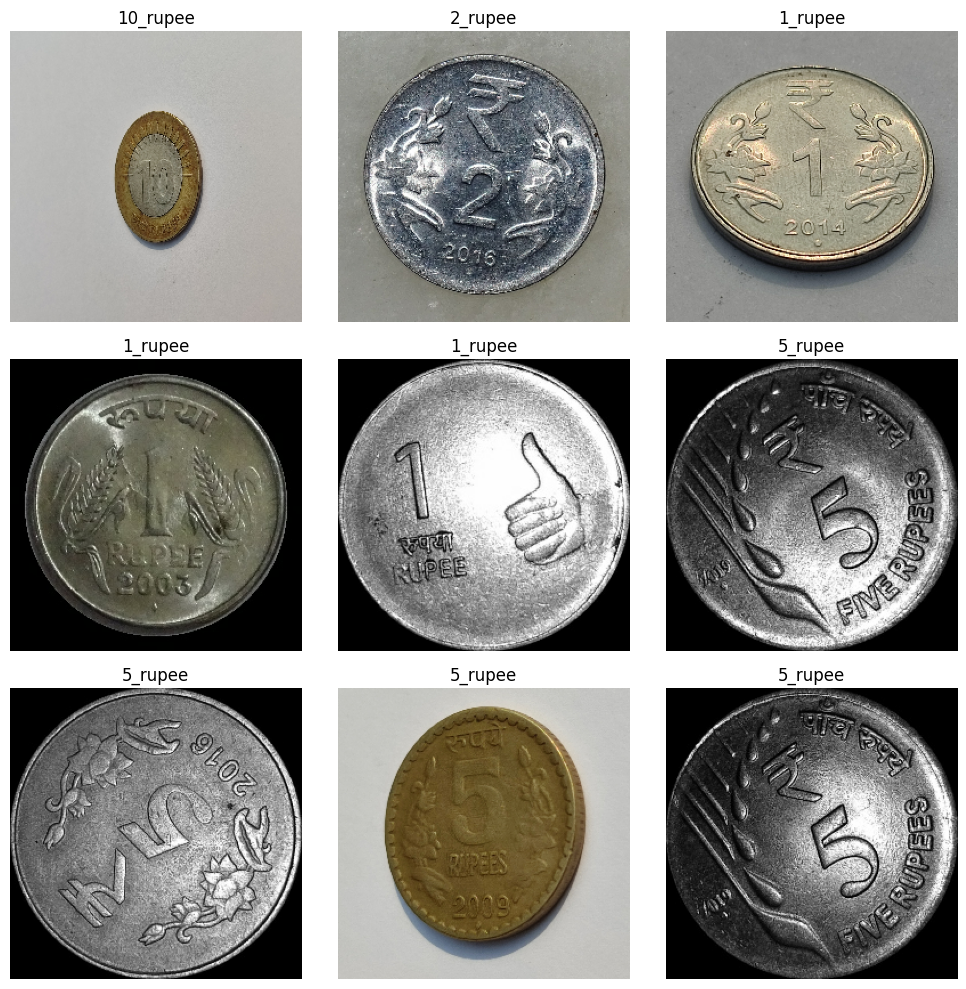

In [ ]:
# Take one batch
images, labels = next(iter(train_dataset))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

# Display first 9 images
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Data Augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Training preprocessing
def train_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = data_augmentation(image)
    return image, label

# Validation preprocessing
def val_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .map(train_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("✅ Dataset Ready")

✅ Dataset Ready


In [ ]:
images, labels = next(iter(train_dataset))

print(images.shape)
print(images.dtype)
print(tf.reduce_min(images).numpy())
print(tf.reduce_max(images).numpy())

(32, 256, 256, 3)
<dtype: 'float32'>
0.0
255.0


In [ ]:
images, labels = next(iter(train_dataset))

print(images.shape)
print(images.dtype)
print(tf.reduce_min(images).numpy())
print(tf.reduce_max(images).numpy())

(32, 256, 256, 3)
<dtype: 'float32'>
0.0
255.0


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = []

for _, labels in train_dataset.unbatch():
    train_labels.append(np.argmax(labels.numpy()))

train_labels = np.array(train_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(1.6275510204081634), 1: np.float64(0.8763736263736264), 2: np.float64(0.8885793871866295), 3: np.float64(0.8935574229691877)}


In [ ]:
# ===============================
# Training Callbacks
# ===============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_coin_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("✅ Callbacks Ready")

✅ Callbacks Ready


In [ ]:
IMG_SHAPE = IMG_SIZE + (3,) # Add color channels
NUM_CLASSES = len(class_names)

def build_classifier_model():
    # Load the pre-trained EfficientNetB0 model without the top classification layer
    base_model = EfficientNetB0(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')

    # Freeze the base model layers to prevent their weights from being updated during training
    base_model.trainable = False

    # Create a new model on top of the pre-trained base
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(NUM_CLASSES, activation='softmax') # Output layer for classification
    ])

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_classifier_model()
model.summary()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4998 - loss: 1.0641
Epoch 1: val_accuracy improved from None to 0.76803, saving model to /content/drive/MyDrive/best_coin_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_coin_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 216s 5s/step - accuracy: 0.6176 - loss: 0.8929 - val_accuracy: 0.7680 - val_loss: 0.7307 - learning_rate: 0.0010
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7487 - loss: 0.6227
Epoch 2: val_accuracy improved from 0.76803 to 0.80564, saving model to /content/drive/MyDrive/best_coin_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_coin_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 205s 5s/step - accuracy: 0.7861 - loss: 0.5822 - val_accuracy: 0.8056 - val_loss: 0.5694 - learning_rate: 0.0010
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8275 - loss: 0.4949
Epoch 3: val_accuracy improved from 0.80564 to 0.86207, saving model to /content

In [ ]:
model.save("/content/drive/MyDrive/best_coin_model.keras")

In [ ]:
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/best_coin_model.keras"
)

loss, acc = best_model.evaluate(val_dataset)

print("\nValidation Loss :", round(loss,4))
print("Validation Accuracy :", round(acc*100,2), "%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9687 - loss: 0.1749

Validation Loss : 0.1749
Validation Accuracy : 96.87 %


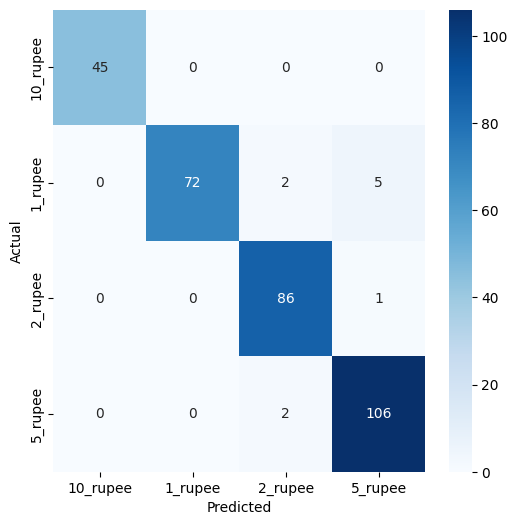

              precision    recall  f1-score   support

    10_rupee       1.00      1.00      1.00        45
     1_rupee       1.00      0.91      0.95        79
     2_rupee       0.96      0.99      0.97        87
     5_rupee       0.95      0.98      0.96       108

    accuracy                           0.97       319
   macro avg       0.98      0.97      0.97       319
weighted avg       0.97      0.97      0.97       319



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = best_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

Saving 2_test_rupee.jpg to 2_test_rupee (3).jpg


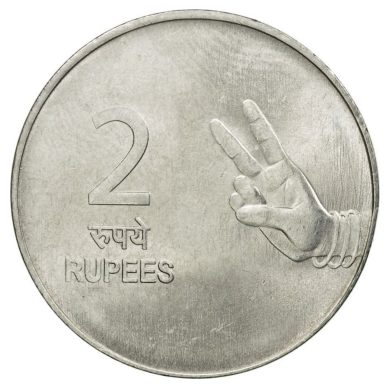

Prediction Probabilities:

10_rupee  : 0.50%
1_rupee   : 39.12%
2_rupee   : 26.66%
5_rupee   : 33.72%

Predicted: 1_rupee


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

# Resize
img = cv2.resize(img, (256, 256))

# Convert to float32
img = img.astype(np.float32)

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Predict
prediction = model.predict(img, verbose=0)

print("Prediction Probabilities:\n")

for cls, prob in zip(class_names, prediction[0]):
    print(f"{cls:10s}: {prob*100:.2f}%")

print("\nPredicted:", class_names[np.argmax(prediction)])

In [ ]:
model.trainable = True

# Freeze first layers
for layer in model.layers[0].layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,              # fine-tune for another 10 epochs
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9464 - loss: 0.1807
Epoch 1: val_accuracy did not improve from 0.97492
40/40 ━━━━━━━━━━━━━━━━━━━━ 224s 5s/step - accuracy: 0.9514 - loss: 0.1745 - val_accuracy: 0.9749 - val_loss: 0.1732 - learning_rate: 1.0000e-05
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9609 - loss: 0.1743
Epoch 2: val_accuracy did not improve from 0.97492
40/40 ━━━━━━━━━━━━━━━━━━━━ 260s 5s/step - accuracy: 0.9585 - loss: 0.1652 - val_accuracy: 0.9749 - val_loss: 0.1719 - learning_rate: 1.0000e-05
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9536 - loss: 0.1775
Epoch 3: val_accuracy did not improve from 0.97492
40/40 ━━━━━━━━━━━━━━━━━━━━ 204s 5s/step - accuracy: 0.9671 - loss: 0.1587 - val_accuracy: 0.9749 - val_loss: 0.1712 - learning_rate: 1.0000e-05
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9511 - loss: 0.1800
Epoch 4: val_accuracy did not improve from 0.97492
40/40 ━━━━━━━━━━━━━━━━━━━━ 205s 

Saving IMG_6245.JPG to IMG_6245 (2).JPG


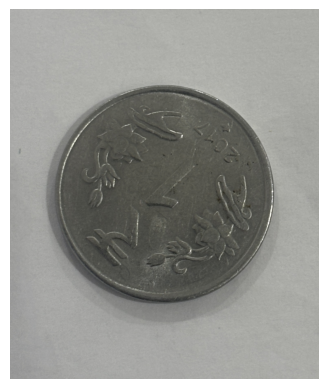

Prediction Probabilities:

10_rupee  : 0.41%
1_rupee   : 42.32%
2_rupee   : 27.84%
5_rupee   : 29.43%

Predicted: 1_rupee


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

# Resize
img = cv2.resize(img, (256, 256))

# Convert to float32
img = img.astype(np.float32)

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Predict
prediction = model.predict(img, verbose=0)

print("Prediction Probabilities:\n")

for cls, prob in zip(class_names, prediction[0]):
    print(f"{cls:10s}: {prob*100:.2f}%")

print("\nPredicted:", class_names[np.argmax(prediction)])